#  Telco Customer Churn Analysis & Prediction

##  Objective:
- Analyze customer behavior
- Identify churn patterns
- Build ML models to predict churn
- Provide business insights to reduce churn

This project analyzes customer churn behavior in a telecom company.
     Goal: Identify key factors driving churn and build a predictive model
to help the business reduce customer loss.

## Libraries Imported

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Check and Handle Missing Values

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

In [7]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

## EDA (WITH BUSINESS INSIGHTS)

In [8]:
# Churn Distribution
fig = px.pie(df, names="Churn", title="Churn Distribution")
fig.show()

💼 Business Insight:
High churn indicates retention issues → company should focus on customer satisfaction strategies.

In [9]:
# . Churn vs Contract Type
fig = px.histogram(df, x="Contract", color="Churn", barmode="group",
                    title="Churn by Contract Type")
fig.show()

💼 Business Insight:
Long-term contracts reduce churn → offer discounts for yearly plans.

In [10]:
#  Monthly Charges vs Churn
fig = px.box(df, x="Churn", y="MonthlyCharges",
             title="Monthly Charges vs Churn")
fig.show()

💼 Business Insight:
Pricing strategy may be too aggressive → consider bundled offers.

In [11]:
#  Tenure vs Churn
fig = px.histogram(df, x="tenure", color="Churn",
                   title="Tenure Distribution")
fig.show()

💼 Business Insight:
First few months are critical → onboarding experience must be improved.

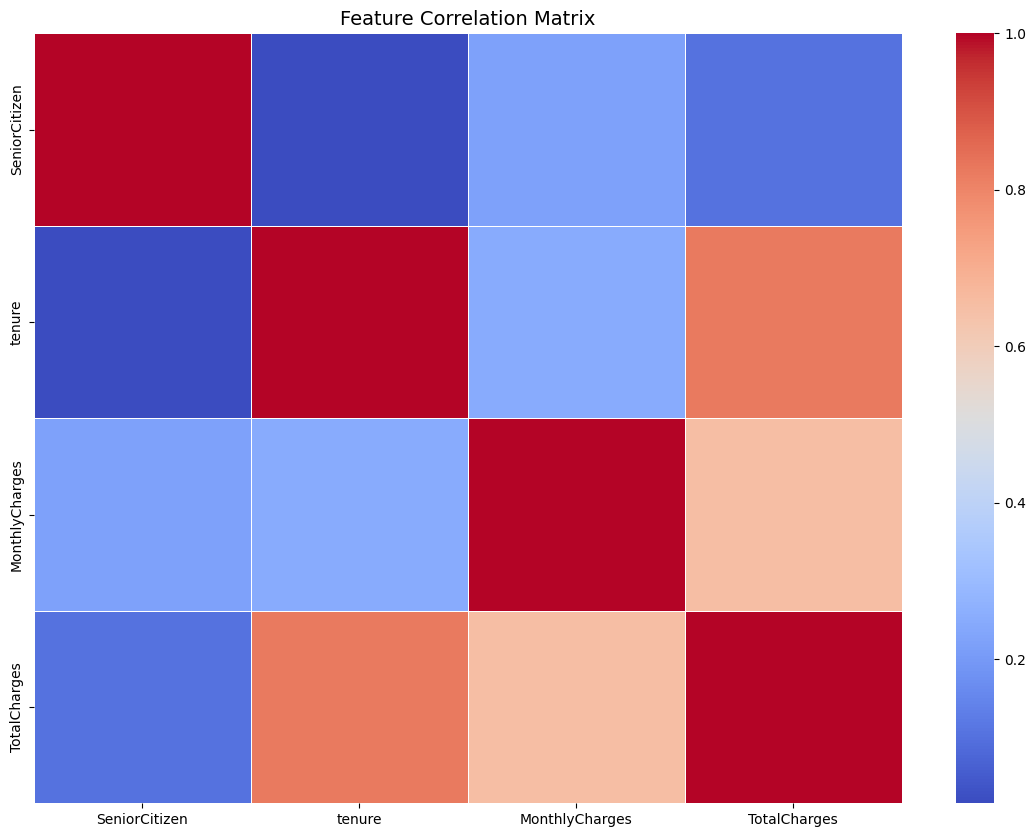

In [14]:
# Create numeric dataframe
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()

## Encoding

In [15]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

## Train-Test Split

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling (for Logistic Regression)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1 — Logistic Regression

In [19]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7853589196872779


## Model 2 — Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7882018479033405


## Model Comparison

In [21]:
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("LR:", lr_acc)
print("RF:", rf_acc)

LR: 0.7853589196872779
RF: 0.7882018479033405


Insight:
Random Forest usually performs better due to handling non-linear patterns.

## Confusion Matrix

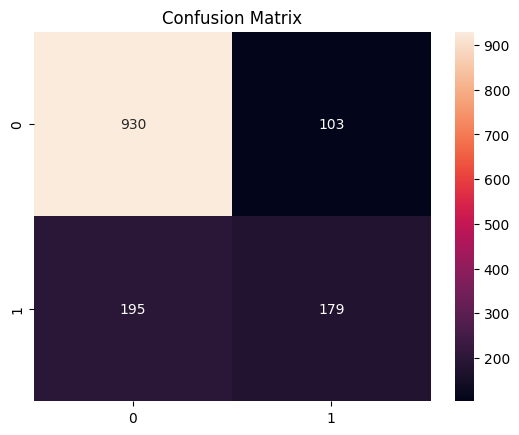

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Feature Importance (Key Business Value)

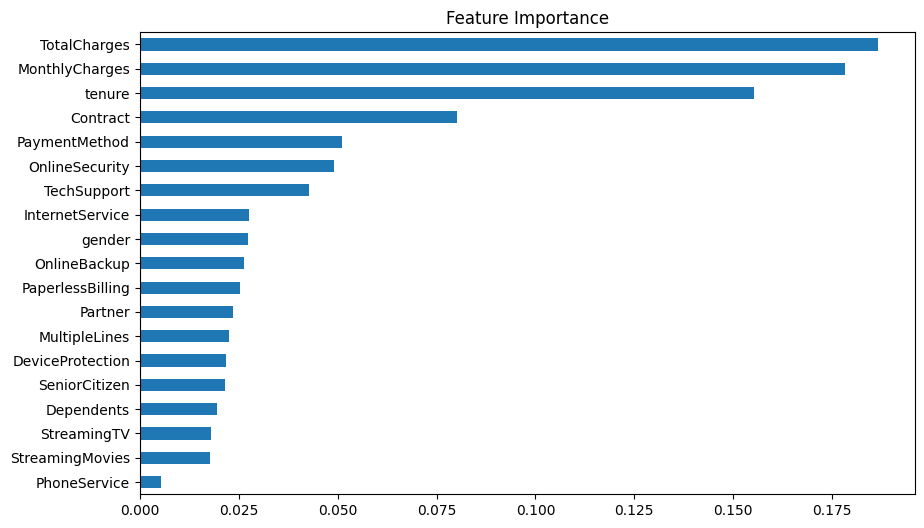

In [23]:
importances = rf.feature_importances_
feat = pd.Series(importances, index=X.columns).sort_values()

feat.plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance")
plt.show()

Business Insight:
Top features directly influence churn → focus retention campaigns on these.

## Final Conclusion:

- Customers with month-to-month contracts, high charges, and low tenure are most likely to churn.
- Random Forest performed better, making it suitable for prediction.
- Business should focus on:
    • Improving onboarding experience
    • Offering long-term plans
    • Optimizing pricing strategies